[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaCoZu/Python/blob/main/pandas/ReDi/01_ReDi_Intro_to_Pandas.ipynb)

In [1]:
import pandas as pd

In [15]:
df = pd.read_csv("data_admin.csv")
df

,school_id,grade,class,student_id,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment,date_of_birth
0,57,6,A,wvqgd@cunb.edu,1,1,2.046285,2.369783,2.711344,1.175309,1.498807,1.840368,1,1997-07-27
1,57,6,A,j0ihe@cunb.edu,1,2,7.859077,7.206984,6.994455,7.548812,6.896719,6.684190,1,1997-06-24
2,57,6,A,wcjgk@cunb.edu,2,1,7.118976,8.057449,8.573210,6.181019,7.119492,7.635253,1,1997-04-23
3,57,6,A,mzmqb@cunb.edu,1,1,6.973737,7.388008,6.628448,7.593102,8.007373,7.247812,1,1997-02-24
4,57,6,A,s6n0y@cunb.edu,1,1,6.574877,6.773626,7.844316,7.611065,7.809814,8.880504,1,1996-09-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,946,8,D,jj36e@cunb.edu,1,1,4.938375,5.306647,4.985917,6.162418,6.530690,6.209960,0,1995-07-04
1506,946,8,D,ca1dg@cunb.edu,1,1,7.661931,8.360153,7.937165,8.179364,8.877586,8.454598,0,1995-08-23
1507,946,8,D,amdrx@cunb.edu,1,1,9.248758,8.534791,8.056641,8.773601,8.059634,7.581484,0,1994-12-15
1508,946,8,D,yn5ug@cunb.edu,1,2,5.689228,5.071503,5.338547,6.382995,5.765270,6.032315,0,1994-09-18


In [ ]:
df["date_of_birth"] = pd.to_datetime(df['date_of_birth'], format="%Y-%m-%d", errors="coerce")
df["age"] = (pd.Timestamp('2000-01-01') - df["date_of_birth"]).dt.days / 365.25

0      1997-07-27
1      1997-06-24
2      1997-04-23
3      1997-02-24
4      1996-09-05
          ...    
1505   1995-07-04
1506   1995-08-23
1507   1994-12-15
1508   1994-09-18
1509   1994-12-19
Name: date_of_birth, Length: 1510, dtype: datetime64[us]

In [51]:
pd.cut(df["grade_math_t1"], 
       bins=[0, 2, 5, 7,10]).value_counts()

grade_math_t1
(7, 10]    691
(5, 7]     559
(2, 5]     254
(0, 2]       5
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   school_id          1510 non-null   int64  
 1   grade              1510 non-null   int64  
 2   class              1510 non-null   str    
 3   student_id         1510 non-null   str    
 4   sex                1510 non-null   int64  
 5   nationality        1510 non-null   int64  
 6   grade_math_t1      1510 non-null   float64
 7   grade_language_t1  1510 non-null   float64
 8   grade_science_t1   1510 non-null   float64
 9   grade_math_t2      1508 non-null   float64
 10  grade_language_t2  1507 non-null   float64
 11  grade_science_t2   1508 non-null   float64
 12  treatment          1510 non-null   int64  
 13  date_of_birth      1510 non-null   str    
dtypes: float64(6), int64(5), str(3)
memory usage: 202.2 KB


In [ ]:
# df.head(20) # see the first o
# df.tail()
# df.info()
df.describe() # five number summary for numeric columns
# df.describe()[["grade_math_t1"]].T # reduce and transpose

,school_id,grade,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1508.000000,1507.000000,1508.000000,1510.000000
mean,457.321192,7.037086,1.203311,1.195364,6.653575,6.628136,6.642331,205.855164,139.605428,205.836261,0.501325
std,315.676789,0.817277,0.402595,0.396612,1.701152,1.713346,1.698250,4456.943949,3641.496348,4456.944784,0.500164
min,57.000000,6.000000,1.000000,1.000000,0.000000,0.993821,0.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,6.000000,1.000000,1.000000,5.563173,5.530065,5.472154,5.635373,5.601699,5.676830,0.000000
50%,458.000000,7.000000,1.000000,1.000000,6.829838,6.775808,6.757819,7.105604,7.058270,7.024505,1.000000
75%,812.000000,8.000000,1.000000,1.000000,7.943985,7.852015,7.921141,8.386922,8.358125,8.406066,1.000000
max,946.000000,8.000000,2.000000,2.000000,10.000000,10.000000,10.000000,99999.000000,99999.000000,99999.000000,1.000000


In [26]:
df.columns

Index(['school_id', 'grade', 'class', 'student_id', 'sex', 'nationality',
       'grade_math_t1', 'grade_language_t1', 'grade_science_t1',
       'grade_math_t2', 'grade_language_t2', 'grade_science_t2', 'treatment',
       'date_of_birth'],
      dtype='str')

In [ ]:
df[['grade_math_t1', 'grade_language_t1', 'grade_science_t1',
       'grade_math_t2', 'grade_language_t2', 'grade_science_t2']]

,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2
0,2.046285,2.369783,2.711344,1.175309,1.498807,1.840368
1,7.859077,7.206984,6.994455,7.548812,6.896719,6.684190
2,7.118976,8.057449,8.573210,6.181019,7.119492,7.635253
3,6.973737,7.388008,6.628448,7.593102,8.007373,7.247812
4,6.574877,6.773626,7.844316,7.611065,7.809814,8.880504
...,...,...,...,...,...,...
1505,4.938375,5.306647,4.985917,6.162418,6.530690,6.209960
1506,7.661931,8.360153,7.937165,8.179364,8.877586,8.454598
1507,9.248758,8.534791,8.056641,8.773601,8.059634,7.581484
1508,5.689228,5.071503,5.338547,6.382995,5.765270,6.032315


In [37]:
df.sample(frac=0.3)

,school_id,grade,class,student_id,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment,date_of_birth
1134,812,7,C,lf6nv@cunb.edu,1,2,3.385581,4.979881,5.043762,5.213995,6.808295,6.872176,1,1996-02-10
588,262,8,D,xva2k@cunb.edu,2,2,5.098769,6.407472,4.746549,6.594872,7.903575,6.242652,0,1995-08-05
1176,812,8,B,ld4nm@cunb.edu,1,1,7.764038,7.711949,8.631476,9.765668,9.713579,10.000000,1,1995-03-04
1179,812,8,B,lsq90@cunb.edu,1,1,8.324262,8.844509,7.892893,9.095559,9.615806,8.664190,1,1994-10-05
1410,946,6,D,cpnpz@cunb.edu,1,1,9.240482,7.565840,8.662684,9.437043,7.762400,8.859245,1,1997-01-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,812,7,D,sczxv@cunb.edu,1,1,2.450305,1.985478,2.196250,2.070312,1.605485,1.816258,0,1996-03-11
301,141,6,A,mwrvy@cunb.edu,1,1,5.498000,5.020906,5.129191,7.494075,7.016981,7.125267,0,1996-11-03
1368,946,6,A,sfjf0@cunb.edu,1,1,4.663616,4.645813,5.201911,5.972681,5.954879,6.510976,1,1997-02-14
1084,812,6,C,b9i0y@cunb.edu,1,1,7.895785,6.825178,6.074223,7.030129,5.959523,5.208568,1,1997-07-01


In [46]:
df["school_id"].unique()

array([ 57,  60, 141, 262, 426, 458, 499, 812, 881, 946])

In [38]:
df["school_id"].value_counts()

school_id
499    161
262    158
426    156
812    153
881    153
57     151
946    150
141    146
60     143
458    139
Name: count, dtype: int64

In [55]:
df[(df["grade_math_t1"]>8) | (df["grade_math_t2"]>8)][["grade_math_t1", "grade_math_t2"]]

,grade_math_t1,grade_math_t2
6,8.611935,7.635252
9,9.039362,8.235168
15,8.775585,7.608807
17,8.758730,8.806232
18,9.150260,9.523394
...,...,...
1490,8.514218,8.327656
1500,8.028151,8.315637
1506,7.661931,8.179364
1507,9.248758,8.773601


In [57]:
df[df["school_id"].isin([499, 57])]

,school_id,grade,class,student_id,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment,date_of_birth
0,57,6,A,wvqgd@cunb.edu,1,1,2.046285,2.369783,2.711344,1.175309,1.498807,1.840368,1,1997-07-27
1,57,6,A,j0ihe@cunb.edu,1,2,7.859077,7.206984,6.994455,7.548812,6.896719,6.684190,1,1997-06-24
2,57,6,A,wcjgk@cunb.edu,2,1,7.118976,8.057449,8.573210,6.181019,7.119492,7.635253,1,1997-04-23
3,57,6,A,mzmqb@cunb.edu,1,1,6.973737,7.388008,6.628448,7.593102,8.007373,7.247812,1,1997-02-24
4,57,6,A,s6n0y@cunb.edu,1,1,6.574877,6.773626,7.844316,7.611065,7.809814,8.880504,1,1996-09-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,499,8,D,9hdrx@cunb.edu,1,1,6.864523,7.906688,8.227232,7.722366,8.764531,9.085075,0,1995-08-03
1050,499,8,D,rxf7l@cunb.edu,1,1,2.023554,1.692102,3.056696,3.451593,3.120141,4.484735,0,1994-12-20
1051,499,8,D,hcxlh@cunb.edu,1,1,6.105133,7.510538,7.745799,6.231407,7.636811,7.872073,0,1995-05-01
1052,499,8,D,qhdq3@cunb.edu,2,2,5.073662,4.617566,4.604944,6.498424,6.042328,6.029706,0,1994-11-08


In [50]:
df[(df["school_id"]==499)] # chooing rows with school_id 499

df[df["school_id"].isin([499, 57])] # choosing rows with school_id 499 or 57

# df[(df["school_id"]==499) | (df["school_id"]==57)] # choosing rows with school_id 499 or 57

# df[(df["school_id"]==499) & (df["grade_math_t1"]>9)] # choosing rows with school_id 499 and grade_math_t1 greater than 9

# df[(df["grade_math_t1"]>9) & (df["grade_math_t2"]>9)] # choosing rows with grade_math_t1 and grade_math_t2 greater than 9

,school_id,grade,class,student_id,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment,date_of_birth
0,57,6,A,wvqgd@cunb.edu,1,1,2.046285,2.369783,2.711344,1.175309,1.498807,1.840368,1,1997-07-27
1,57,6,A,j0ihe@cunb.edu,1,2,7.859077,7.206984,6.994455,7.548812,6.896719,6.684190,1,1997-06-24
2,57,6,A,wcjgk@cunb.edu,2,1,7.118976,8.057449,8.573210,6.181019,7.119492,7.635253,1,1997-04-23
3,57,6,A,mzmqb@cunb.edu,1,1,6.973737,7.388008,6.628448,7.593102,8.007373,7.247812,1,1997-02-24
4,57,6,A,s6n0y@cunb.edu,1,1,6.574877,6.773626,7.844316,7.611065,7.809814,8.880504,1,1996-09-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,499,8,D,9hdrx@cunb.edu,1,1,6.864523,7.906688,8.227232,7.722366,8.764531,9.085075,0,1995-08-03
1050,499,8,D,rxf7l@cunb.edu,1,1,2.023554,1.692102,3.056696,3.451593,3.120141,4.484735,0,1994-12-20
1051,499,8,D,hcxlh@cunb.edu,1,1,6.105133,7.510538,7.745799,6.231407,7.636811,7.872073,0,1995-05-01
1052,499,8,D,qhdq3@cunb.edu,2,2,5.073662,4.617566,4.604944,6.498424,6.042328,6.029706,0,1994-11-08


In [ ]:
df[:10] # first 10 rows
# df[10:20] # rows 10 to 19
# df[-10:] # last 10 rows

In [ ]:
df.loc[70:80, ["school_id", "grade_math_t1", "grade_math_t2"]] 

,school_id,grade_math_t1,grade_math_t2
70,57,4.444157,2.586029
71,57,6.920554,7.742517
72,57,5.579360,6.668370
73,57,4.739767,4.372147
74,57,7.570126,8.737879
75,57,5.348467,3.711765
76,57,5.437468,6.008863
77,57,7.600618,8.049394
78,57,6.542240,5.838142
79,57,7.146052,7.366829


In [ ]:
df.iloc[:, :3] # first three columns
# df.iloc[:, -3:] # last three columns
# df.iloc[:, 3:6] # columns 3 to 5
# df.iloc[10:20, 3:6] # rows 10 to 19 and columns 3 to 5

# df.iloc[df["school_id"]==499, 3:6] # rows with school_id 499 and columns 3 to 5

In [75]:
df.query("school_id == 499 or grade_math_t1 > 9")

,school_id,grade,class,student_id,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment,date_of_birth
9,57,6,A,crjpx@cunb.edu,1,1,9.039362,9.126943,8.789369,8.235168,8.322749,7.985175,1,1996-10-24
18,57,6,B,gca3x@cunb.edu,1,1,9.150260,9.432889,8.127485,9.523394,9.806023,8.500619,0,1997-07-05
31,57,6,C,0eiwm@cunb.edu,1,1,9.737252,10.000000,8.927517,10.000000,10.000000,9.194739,1,1997-03-25
81,57,7,C,ysvls@cunb.edu,1,1,9.604527,8.388494,9.063802,10.000000,9.936316,10.000000,0,1996-07-29
88,57,7,C,7pojk@cunb.edu,1,1,9.267352,8.130984,8.006577,10.000000,9.512149,9.387742,0,1996-02-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,946,8,A,eohgp@cunb.edu,1,1,9.768719,10.000000,8.493072,9.515601,9.746882,8.239953,0,1994-12-19
1469,946,8,A,9zjxw@cunb.edu,1,1,9.726560,8.543301,9.302289,10.000000,9.631962,10.000000,0,1995-03-20
1471,946,8,A,opwwd@cunb.edu,1,1,9.931566,9.399936,9.087036,9.821719,9.290089,8.977189,0,1995-05-22
1507,946,8,D,amdrx@cunb.edu,1,1,9.248758,8.534791,8.056641,8.773601,8.059634,7.581484,0,1994-12-15


In [ ]:
df.query("school_id==499 and grade_math_t1>9") 
# df.query("school_id==499 and grade_math_t1>9").iloc[:, 3:6] 
df.query("school_id==499 and grade_math_t1>9").iloc[:, [0, 3, 6]] 
# df.query("school_id==499 and grade_math_t1>9")[["school_id","student_id", "grade_math_t1"]] 

In [88]:
(
    df.groupby("school_id")
    [["grade_math_t1", "grade_math_t2"]]
    .mean()
    .sort_values("grade_math_t1", ascending=True)
)


,grade_math_t1,grade_math_t2
school_id,,
57,6.525833,669.007044
60,6.568582,6.759094
426,6.588012,6.928300
262,6.592350,6.930369
458,6.606627,6.828956
812,6.692626,7.147510
881,6.698419,660.556578
499,6.716349,7.078013
141,6.727879,691.856133


In [ ]:
# df.groupby("school_id")["grade_math_t1"].mean()
df.groupby("school_id")["grade_math_t1"].max() # sum(), mean(), count(), std(), min(), max(), median(), quantile

In [ ]:
df.groupby("school_id")["grade_math_t1"].agg(["mean", "std", "min", "max", "median"])

In [ ]:
df["class"].count()
df["class"].nunique()
df["class"].unique()
df.groupby(["class"]).count()
df["class"].value_counts()

In [ ]:
# feature engeneering
df["math_diff"] = df["grade_math_t2"] - df["grade_math_t1"]
df

<Axes: xlabel='class'>

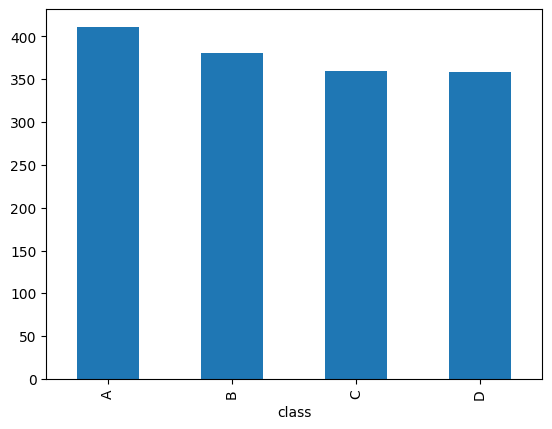

In [89]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
df["class"].value_counts().plot(kind="bar") # discover plot properties, try to sort the bars, add labels, title, etc.

<Axes: xlabel='grade_math_t1', ylabel='grade_math_t2'>

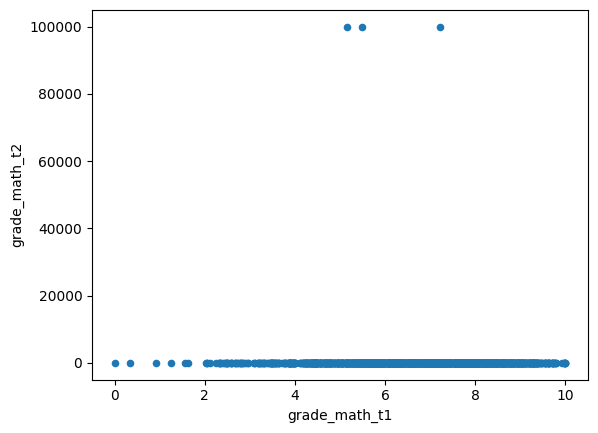

In [ ]:
df.plot(x="grade_math_t1", y="grade_math_t2", kind="scatter") # outliers distorted the plot

<Axes: xlabel='grade_math_t1', ylabel='grade_math_t2'>

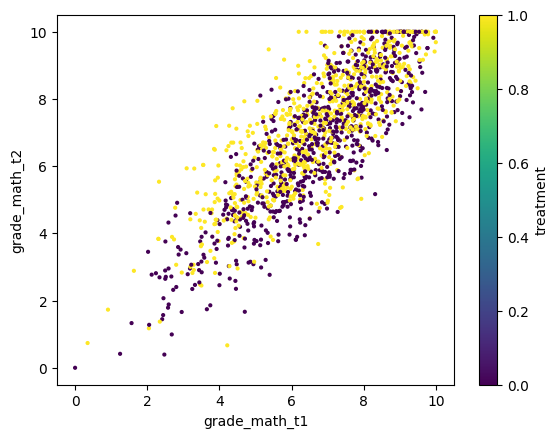

In [93]:
# df[df["grade_math_t2"]<=10].plot(x="grade_math_t1", y="grade_math_t2", kind="scatter", c="lightblue")
df[df["grade_math_t2"]<=10].plot.scatter(x="grade_math_t1", y="grade_math_t2", c="treatment", colormap="viridis", s=4)

<Axes: xlabel='grade_math_t1', ylabel='grade_math_t2'>

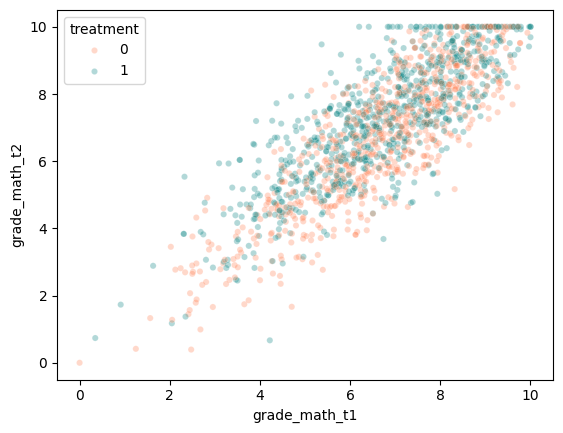

In [94]:
import seaborn as sns
sns.scatterplot(data=df[df["grade_math_t2"]<=10], x="grade_math_t1", y="grade_math_t2", hue="treatment", palette=["coral", "teal"], s=20, alpha=0.3)

<Axes: xlabel='grade_math_t1', ylabel='grade_math_t2'>

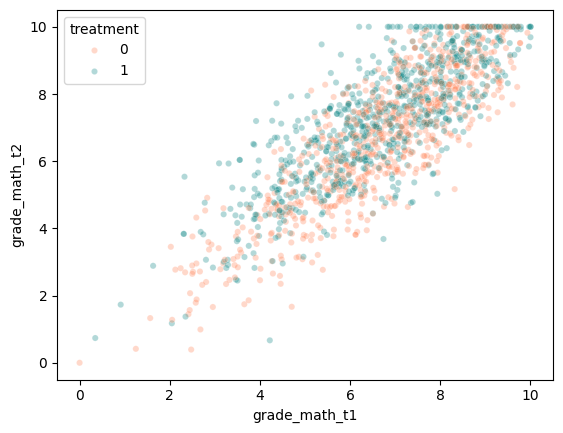

In [95]:
# use parentheses for better formatting of long code lines
(
    sns.scatterplot(
        data=df[df["grade_math_t2"] <= 10], 
        x="grade_math_t1", 
        y="grade_math_t2", 
        hue="treatment", 
        palette=["coral", "teal"], 
        s=20, 
        alpha=0.3
    )
)

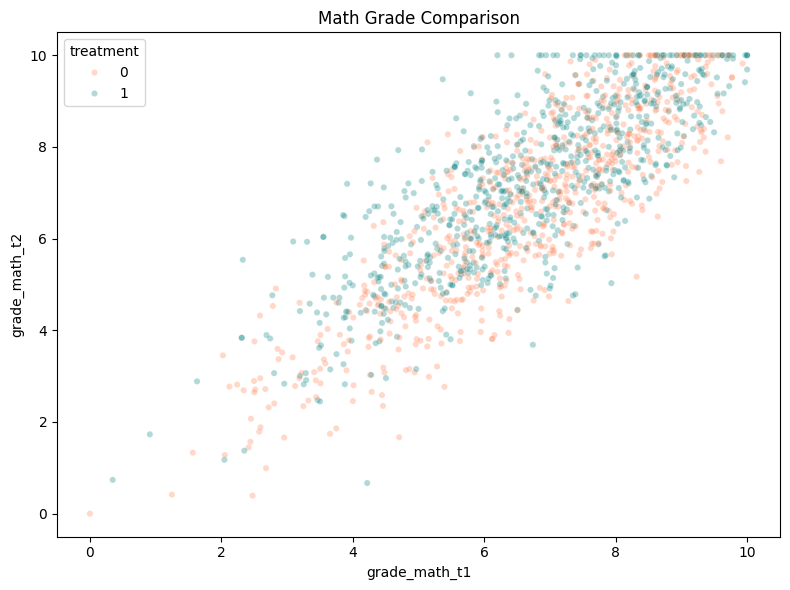

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt


# define a function for recurring tasks
def plot_scatter(df):
    dfc = df[df["grade_math_t2"] <= 10] # data cleaning

    plt.figure(figsize=(8, 6))
    
    # Assigning to a variable is optional if you just want to show it
    sns.scatterplot(
        data=dfc, 
        x="grade_math_t1", 
        y="grade_math_t2", 
        hue="treatment", 
        palette=["coral", "teal"], 
        s=20, 
        alpha=0.3,
    )
    
    
    plt.title("Math Grade Comparison") # add a title
    plt.tight_layout()
    plt.show() # This renders the plot cleanly

plot_scatter(df)

# Exercises

1. tweak the csv_read() function ensuring the date_of_birth column is recognized as a date.

2. write a boolean index for nationality = 1

3. find the average grade_math_t1 specifically for female ('F') students.

3. find all rows where 'grade_math_t1 and grade_science_t2 > 9.5

4. find all students born after 1997-01-01

5. create a new column called avg_math which contains the average math scores per student (grade_math_t1 + grade_math_t2)/2

6. find outliers.

7. use the .query() method to find all **female** students in grade 6.

8. calculate the median score for grade_science_t2 and compare it to the mean. What does this suggest about the distribution?

9. find the average grade_math_t1 scores for all students with treatment = 1 and average grade_math_t1 scores with treatment = 0 and compare.

10. create a histogram of grade_math_t1 with 100 bins.

# Pandas Reference

## pd.read_csv()
The primary way to load data. Think of this as defining your source table.

**sep**:

Defines the character used to separate columns. Defaults to `,`.

`df = pd.read_csv("data.csv", sep=";")`

**encoding**: 

If you see weird symbols or "UnicodeDecodeErrors," try 'utf-8', 'latin1', or 'cp1252'.

`df = pd.read_csv("data.csv", encoding='latin1')`

**parse_dates**:

Pass a list of columns to convert them to datetime objects immediately.

`df = pd.read_csv("data.csv", parse_dates=["date_of_birth"])`

---

## Column Selection
In SQL, this is your `SELECT` clause.

**Single column**: 

`df['grade']`

Returns a **Series** (a single column of data).


**Multiple columns**:

Returns a **DataFrame**. Note the double brackets.

`df[['student_id', 'grade']]`

**Slicing**:

Selects a range of rows by position index.

`df[0:10]` (Returns the first 10 rows).

---

## Row Selection (Filtering)
In SQL, these are your `WHERE` clauses.

**Boolean Indexing**

Filtering the dataframe based on a logical condition. You may use `==, <, >, <=, >=, !=, ~`

`df[df['grade'] > 9]`

`df[~df['grade'] > 9]` ~ is a logical NOT, so it amounts to `df['grade'] < 9` 

The inner condition (`df['grade'] > 10`) returns a Series of **True/False** values. Wrapping it in `df[]` returns only the **True** rows.

**df.query()**

Allows you to filter using a string expression. Very similar to SQL syntax.

`df.query("grade > 10 and sex == 'F'")`

**df.loc[]**

Label-based selection. Best for selecting specific rows and columns at the same time.

`df.loc[df['grade'] > 10, ['student_id', 'sex']]`

*(The first part filters rows; the second part selects columns).*

**df.sample()**

Returns a random subset of rows. Useful for a quick data audit.

`df.sample(n=5)`

---

### Values & Counts
In SQL, these are your `COUNT(col)`, `DISTINCT`, and `GROUP BY col, COUNT(*)` operations.

**count()**: 

Counts the number of non-null values in a column.

`df['nationality'].count()`

**unique()**: 

Returns an array of all unique values in a column. Similar to `SELECT DISTINCT`.

`df['grade'].unique()`

**nunique()**: 

Returns the **number** of unique values. Similar to `COUNT(DISTINCT col)`.

`df['school_id'].nunique()`

**value_counts()**: 

Returns a list of all unique values and how many times they appear. This is the pandas shortcut for `GROUP BY` and `COUNT` and reveals the distribution of your categories.

`df['sex'].value_counts()`


---

## Aggregations & Visualizations

**Basic Statistics**

Quickly summarize numerical data.

`df['grade_math_t1'].mean()` (Average)

`df.describe()` (Summary statistics for all columns)

**Simple Plotting**

Pandas has built-in integration with Matplotlib.

`df['grade_math_t1'].hist()` (Histogram)

`df.plot.scatter(x='grade_math_t1', y='grade_science_t1')` (Scatter plot)

**Pandas plot**
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html

**Color maps**
https://matplotlib.org/stable/users/explain/colors/colormaps.html


---

**Cheat Sheet**
https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

**Official Documentation:**
[pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) | [Indexing and Selecting Data](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)